# Домашнее задание 1.3. Орбитальное движение в 2D

**Уровень:** 🟢  
**Выполнил:** Константин Мурусидзе, 6 курс мехмата МГУ

Цель работы — реализовать методы Эйлера и Рунге—Кутты четвёртого порядка (RK4) для движения тела в поле неподвижного притягивающего центра и сравнить численные решения с точным.


## 1. Постановка задачи

Рассматривается безразмерное уравнение

$$
\ddot{\mathbf r}=-\frac{\mathbf r}{|\mathbf r|^3},
\qquad \mathbf r=(x,y).
$$

Введём вектор состояния

$$
\mathbf y=(x,y,v_x,v_y)^T.
$$

Тогда задача записывается как система первого порядка:

$$
\dot{\mathbf y}=
\begin{pmatrix}
v_x\\v_y\\-x/r^3\\-y/r^3
\end{pmatrix},
\qquad r=\sqrt{x^2+y^2}.
$$

Используются начальные условия

$$
\mathbf r(0)=(1,0), \qquad \dot{\mathbf r}(0)=(0,1).
$$

Для них точное решение имеет вид

$$
\mathbf r(t)=(\cos t,\sin t),
$$

а период обращения равен $T=2\pi$.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


## 2. Численные методы

Для одного шага метода Эйлера используется формула

$$
\mathbf y_{n+1}=\mathbf y_n+h f(t_n,\mathbf y_n).
$$

Метод RK4 вычисляет четыре промежуточных значения правой части и имеет четвёртый порядок точности.


In [7]:
def rhs(_t, state):
    position = state[:2]
    velocity = state[2:]
    radius = np.linalg.norm(position)
    acceleration = -position / radius**3
    return np.hstack((velocity, acceleration))


def euler_step(fun, t, state, h):
    return state + h * fun(t, state)


def rk4_step(fun, t, state, h):
    k1 = fun(t, state)
    k2 = fun(t + h/2, state + h*k1/2)
    k3 = fun(t + h/2, state + h*k2/2)
    k4 = fun(t + h, state + h*k3)
    return state + h * (k1 + 2*k2 + 2*k3 + k4) / 6


def integrate(fun, initial_state, t_end, h, stepper):
    # Сетка подбирается так, чтобы последняя точка совпадала с t_end.
    n_steps = int(np.ceil(t_end / h))
    time = np.linspace(0.0, t_end, n_steps + 1)
    states = np.empty((n_steps + 1, len(initial_state)))
    states[0] = initial_state

    for i, dt in enumerate(np.diff(time)):
        states[i + 1] = stepper(fun, time[i], states[i], dt)

    return time, states


def exact_position(time):
    return np.column_stack((np.cos(time), np.sin(time)))


## 3. Сравнение с точным решением

Проведём расчёт одного полного оборота для нескольких шагов. В качестве ошибки используется расстояние между численным и точным положением тела в момент $T=2\pi$:

$$
\varepsilon=\|\mathbf r_{num}(T)-\mathbf r_{exact}(T)\|.
$$


In [8]:
initial_state = np.array([1.0, 0.0, 0.0, 1.0])
T = 2 * np.pi
h_values = [0.20, 0.10, 0.05, 0.025]

solutions = {}
rows = []

for method_name, stepper in [("Euler", euler_step), ("RK4", rk4_step)]:
    for h in h_values:
        time, states = integrate(rhs, initial_state, T, h, stepper)
        exact = exact_position(time)
        error = np.linalg.norm(states[-1, :2] - exact[-1])
        actual_h = time[1] - time[0]
        rows.append((method_name, actual_h, error))
        solutions[(method_name, h)] = (time, states, exact)

print(f"{'Метод':<8} {'Шаг':>10} {'Ошибка в момент T':>20}")
for method_name, h, error in rows:
    print(f"{method_name:<8} {h:10.5f} {error:20.6e}")


Метод           Шаг    Ошибка в момент T
Euler       0.19635         3.861002e+00
Euler       0.09973         2.881023e+00
Euler       0.04987         1.960719e+00
Euler       0.02493         1.198685e+00
RK4         0.19635         4.524823e-04
RK4         0.09973         2.233419e-05
RK4         0.04987         1.143646e-06
RK4         0.02493         6.356948e-08


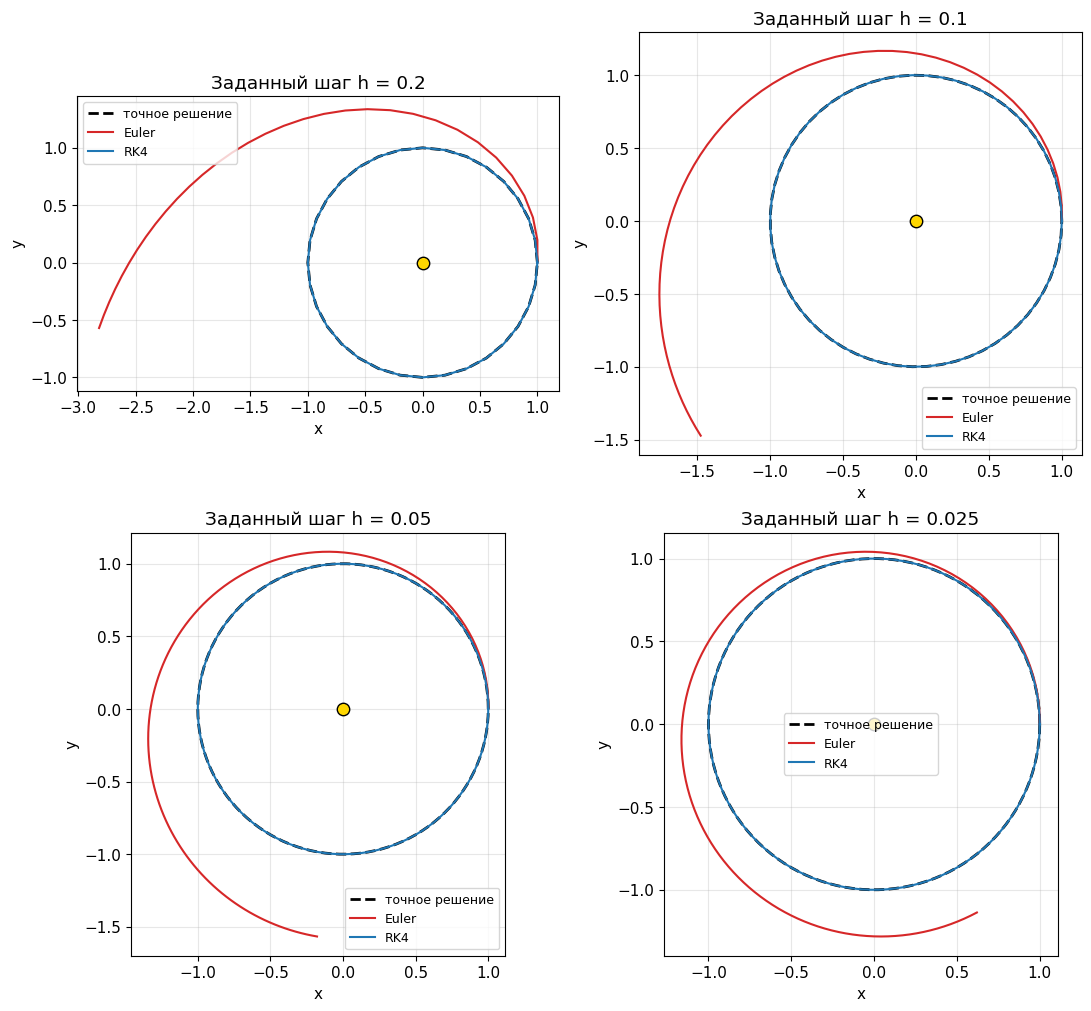

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)

for ax, h in zip(axes.flat, h_values):
    time_e, states_e, exact_e = solutions[("Euler", h)]
    time_r, states_r, exact_r = solutions[("RK4", h)]

    ax.plot(exact_r[:, 0], exact_r[:, 1], "k--", lw=2, label="точное решение")
    ax.plot(states_e[:, 0], states_e[:, 1], color="tab:red", label="Euler")
    ax.plot(states_r[:, 0], states_r[:, 1], color="tab:blue", label="RK4")
    ax.scatter([0], [0], s=80, c="gold", edgecolors="black", zorder=5)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Заданный шаг h = {h}")
    ax.legend(fontsize=9)

plt.show()


## 4. Энергия и момент импульса

Полная механическая энергия и момент импульса относительно притягивающего центра вычисляются по формулам

$$
E=\frac{v_x^2+v_y^2}{2}-\frac{1}{r},
\qquad
L=xv_y-yv_x.
$$

Для точного решения обе величины постоянны: $E=-1/2$, $L=1$.


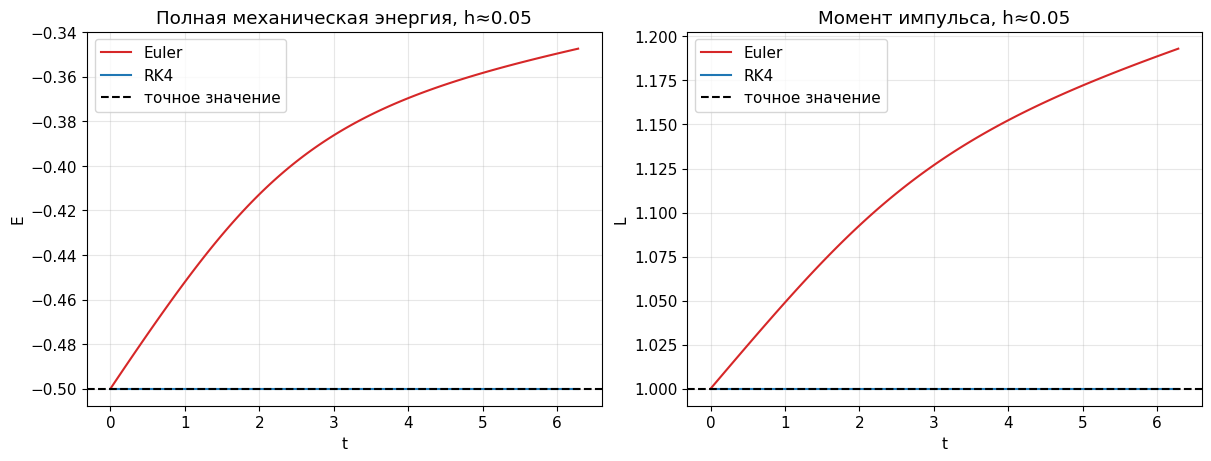

In [10]:
def energy(states):
    radius = np.linalg.norm(states[:, :2], axis=1)
    speed_squared = np.sum(states[:, 2:]**2, axis=1)
    return 0.5 * speed_squared - 1.0 / radius


def angular_momentum(states):
    return states[:, 0] * states[:, 3] - states[:, 1] * states[:, 2]


h_diagnostics = 0.05
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for method_name, color in [("Euler", "tab:red"), ("RK4", "tab:blue")]:
    time, states, _ = solutions[(method_name, h_diagnostics)]
    axes[0].plot(time, energy(states), color=color, label=method_name)
    axes[1].plot(time, angular_momentum(states), color=color, label=method_name)

axes[0].axhline(-0.5, color="black", ls="--", label="точное значение")
axes[1].axhline(1.0, color="black", ls="--", label="точное значение")
axes[0].set_xlabel("t")
axes[0].set_ylabel("E")
axes[0].set_title(f"Полная механическая энергия, h≈{h_diagnostics}")
axes[1].set_xlabel("t")
axes[1].set_ylabel("L")
axes[1].set_title(f"Момент импульса, h≈{h_diagnostics}")
axes[0].legend()
axes[1].legend()
plt.show()


## 5. Выводы

1. Метод Эйлера при выбранных шагах заметно отклоняется от точной круговой орбиты. Энергия и момент импульса возрастают, поэтому орбита раскручивается наружу.
2. При уменьшении шага результат метода Эйлера приближается к точному решению, однако ошибка остаётся существенно больше, чем у RK4.
3. Метод RK4 уже при сравнительно крупном шаге хорошо воспроизводит круговую орбиту и почти сохраняет энергию и момент импульса на одном периоде.
4. Для обоих методов уменьшение шага повышает точность, но RK4 сходится значительно быстрее.
